# Tema 7 - Circuitos de Corriente Alterna

**Teoría de Circuitos - ETSI, Universidad de Sevilla**

---

## Objetivos de aprendizaje

- Comprender el régimen permanente sinusoidal y la representación fasorial
- Calcular impedancias y admitancias de R, L y C en el dominio de la frecuencia
- Aplicar la ley de Ohm fasorial y las leyes de Kirchhoff con fasores
- Resolver circuitos de CA mediante análisis nodal y de mallas con números complejos
- Calcular valores eficaces (RMS) de señales sinusoidales y periódicas
- Analizar la respuesta transitoria en circuitos de corriente alterna

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
import schemdraw
import schemdraw.elements as elm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'   # azul - curvas principales, datos
COLOR_RECTA = '#cb181d'       # rojo - rectas de carga, límites
COLOR_PUNTO = '#238b45'       # verde - puntos de operación, resultados
COLOR_FASE = '#e6550d'        # naranja - desfase, componente imaginaria
COLOR_ENVOL = '#756bb1'       # púrpura - envolvente transitoria

print('Configuración lista.')

Configuración lista.


---

## 1. Régimen permanente sinusoidal

### 1.1 Concepto fundamental

Cuando aplicamos una fuente sinusoidal a un circuito lineal, la respuesta tiene dos componentes:

1. **Respuesta natural (transitorio)**: depende de las condiciones iniciales y decae exponencialmente
2. **Respuesta forzada (permanente)**: es sinusoidal, con la **misma frecuencia** que la fuente

Tras un tiempo suficiente, el transitorio se extingue y solo queda la **respuesta permanente sinusoidal**:

$$\boxed{v(t) = \sqrt{2} \cdot V \cdot \cos(\omega t + \varphi)}$$

donde:
- $V$ = valor eficaz (RMS) de la tensión
- $\omega = 2\pi f$ = frecuencia angular (rad/s)
- $\varphi$ = fase inicial (rad)
- $\sqrt{2} \cdot V$ = valor de pico (amplitud máxima)

> **Idea clave**: en régimen permanente, todas las tensiones y corrientes del circuito son sinusoidales de la misma frecuencia $\omega$. Solo difieren en **amplitud** y **fase**.

---

## 2. Fasores (*phasors*)

### 2.1 Definición

Un **fasor** es un número complejo que representa una señal sinusoidal en régimen permanente:

$$v(t) = \sqrt{2} \cdot V \cdot \cos(\omega t + \varphi) \quad \longleftrightarrow \quad \mathbf{V} = V \angle \varphi = V \cdot e^{j\varphi}$$

| Forma | Expresión | Uso |
|-------|-----------|-----|
| Polar | $V \angle \varphi$ | Multiplicación, división |
| Exponencial | $V \cdot e^{j\varphi}$ | Operaciones generales |
| Rectangular | $V\cos\varphi + jV\sin\varphi$ | Suma, resta |

### 2.2 Conversión tiempo $\to$ fasor

1. Identificar amplitud de pico $V_p = \sqrt{2} \cdot V$ y fase $\varphi$
2. El fasor es $\mathbf{V} = \dfrac{V_p}{\sqrt{2}} \angle \varphi = V \angle \varphi$

### 2.3 Conversión fasor $\to$ tiempo

1. Del fasor $\mathbf{V} = V \angle \varphi$ extraer $V$ y $\varphi$
2. La señal es $v(t) = \sqrt{2} \cdot V \cdot \cos(\omega t + \varphi)$

### 2.4 Derivada e integral en dominio fasorial

$$\boxed{\frac{d}{dt} \longleftrightarrow j\omega \qquad \int dt \longleftrightarrow \frac{1}{j\omega}}$$

Derivar una sinusoide equivale a multiplicar su fasor por $j\omega$. Integrar equivale a dividir por $j\omega$.

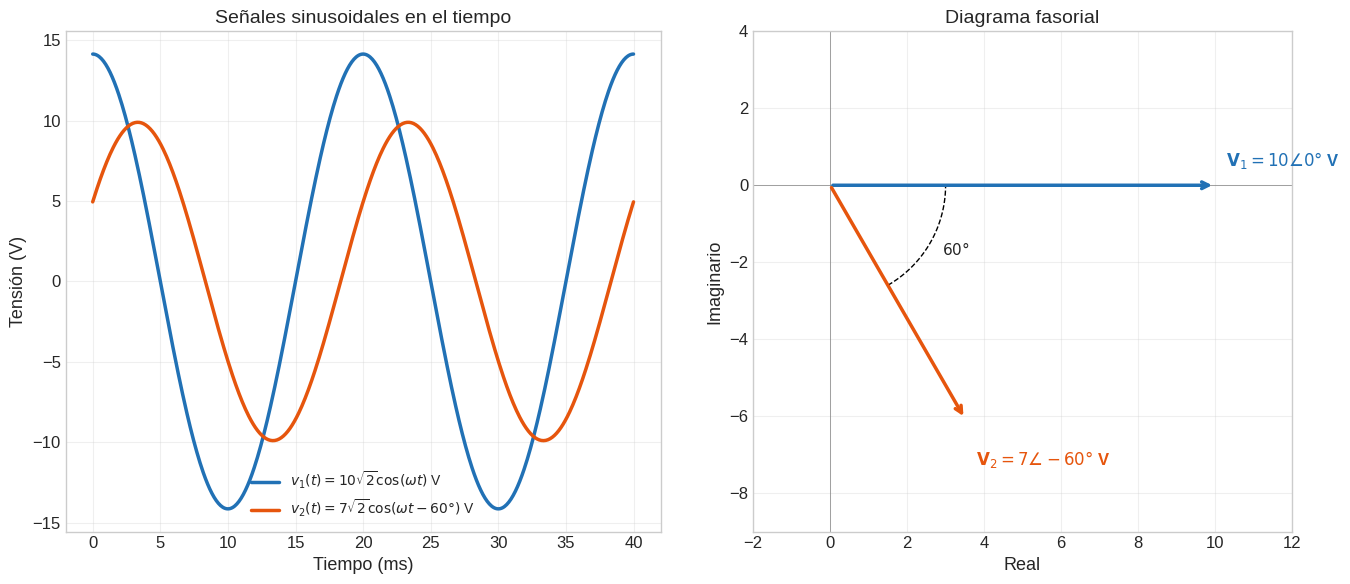

In [2]:
# Diagrama fasorial de dos tensiones
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel izquierdo: señales en el tiempo ---
t = np.linspace(0, 0.04, 500)
omega = 2 * np.pi * 50  # 50 Hz
V1, phi1 = 10, 0              # V1 = 10∠0°
V2, phi2 = 7, np.radians(-60) # V2 = 7∠-60°

v1 = np.sqrt(2) * V1 * np.cos(omega * t + phi1)
v2 = np.sqrt(2) * V2 * np.cos(omega * t + phi2)

axes[0].plot(t * 1e3, v1, color=COLOR_PRINCIPAL, lw=2.5, label=r'$v_1(t) = 10\sqrt{2}\cos(\omega t)$ V')
axes[0].plot(t * 1e3, v2, color=COLOR_FASE, lw=2.5, label=r'$v_2(t) = 7\sqrt{2}\cos(\omega t - 60°)$ V')
axes[0].set_xlabel(r'Tiempo (ms)')
axes[0].set_ylabel(r'Tensión (V)')
axes[0].set_title('Señales sinusoidales en el tiempo')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Panel derecho: diagrama fasorial ---
ax = axes[1]
ax.set_aspect('equal')

# Flechas fasoriales
ax.annotate('', xy=(V1 * np.cos(phi1), V1 * np.sin(phi1)), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=2.5))
ax.annotate('', xy=(V2 * np.cos(phi2), V2 * np.sin(phi2)), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color=COLOR_FASE, lw=2.5))

ax.text(V1 * np.cos(phi1) + 0.3, V1 * np.sin(phi1) + 0.5,
        r'$\mathbf{V}_1 = 10\angle 0°$ V', fontsize=12, color=COLOR_PRINCIPAL, fontweight='bold')
ax.text(V2 * np.cos(phi2) + 0.3, V2 * np.sin(phi2) - 1.2,
        r'$\mathbf{V}_2 = 7\angle -60°$ V', fontsize=12, color=COLOR_FASE, fontweight='bold')

# Arco de desfase
theta_arc = np.linspace(phi2, phi1, 50)
r_arc = 3.0
ax.plot(r_arc * np.cos(theta_arc), r_arc * np.sin(theta_arc), 'k--', lw=1)
ax.text(r_arc * np.cos(phi2 / 2) + 0.3, r_arc * np.sin(phi2 / 2) - 0.3,
        r'$60°$', fontsize=11)

# Ejes
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlim(-2, 12)
ax.set_ylim(-9, 4)
ax.set_xlabel(r'Real')
ax.set_ylabel(r'Imaginario')
ax.set_title('Diagrama fasorial')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 3. Impedancia y admitancia

### 3.1 Impedancia

La **impedancia** $\mathbf{Z}$ es la relación entre el fasor de tensión y el fasor de corriente:

$$\boxed{\mathbf{Z} = \frac{\mathbf{V}}{\mathbf{I}} = R + jX \quad [\Omega]}$$

donde $R$ = **resistencia** (parte real) y $X$ = **reactancia** (parte imaginaria).

### 3.2 Admitancia

La **admitancia** $\mathbf{Y}$ es la inversa de la impedancia:

$$\boxed{\mathbf{Y} = \frac{1}{\mathbf{Z}} = \frac{\mathbf{I}}{\mathbf{V}} = G + jB \quad [\text{S}]}$$

donde $G$ = **conductancia** y $B$ = **susceptancia**.

### 3.3 Impedancias de los elementos pasivos

| Elemento | Impedancia $\mathbf{Z}$ | Admitancia $\mathbf{Y}$ | Tensión-corriente |
|----------|-------------------------|-------------------------|-------------------|
| Resistor | $Z_R = R$ | $Y_R = G = \dfrac{1}{R}$ | $V$ e $I$ **en fase** |
| Inductor | $Z_L = j\omega L$ | $Y_L = \dfrac{1}{j\omega L}$ | $V$ **adelanta** $90°$ a $I$ |
| Condensador | $Z_C = \dfrac{1}{j\omega C}$ | $Y_C = j\omega C$ | $I$ **adelanta** $90°$ a $V$ |

> **Regla mnemotécnica (ELI the ICE man)**: En un inductor (L), la tensión (E) adelanta a la corriente (I). En un condensador (C), la corriente (I) adelanta a la tensión (E).

In [ ]:
# Impedancias en el plano complejo
fig, ax = plt.subplots(figsize=(10, 8))

# Parámetros
R = 100       # Ω
L = 50e-3     # H
C = 20e-6     # F
omega = 2 * np.pi * 50  # 50 Hz

Z_R = complex(R, 0)
Z_L = complex(0, omega * L)
Z_C = complex(0, -1 / (omega * C))
Z_total = Z_R + Z_L + Z_C

# Dibujar impedancias como vectores
impedances = [
    (Z_R, r'$Z_R = 100\;\Omega$', COLOR_PRINCIPAL),
    (Z_L, r'$Z_L = j%.1f\;\Omega$' % Z_L.imag, COLOR_FASE),
    (Z_C, r'$Z_C = -j%.1f\;\Omega$' % abs(Z_C.imag), COLOR_PUNTO),
    (Z_total, r'$Z_{total} = %.1f %+.1fj\;\Omega$' % (Z_total.real, Z_total.imag), COLOR_RECTA),
]

for Z, label, color in impedances:
    ax.annotate('', xy=(Z.real, Z.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    offset_x = 5 if Z.real >= 0 else -40
    offset_y = 10 if Z.imag >= 0 else -15
    ax.text(Z.real + offset_x, Z.imag + offset_y, label,
            fontsize=12, color=color, fontweight='bold')

# Serie: vector suma paso a paso
ax.annotate('', xy=(Z_R.real, Z_L.imag), xytext=(Z_R.real, 0),
            arrowprops=dict(arrowstyle='->', color=COLOR_FASE, lw=1.5, ls='--'))
ax.annotate('', xy=(Z_total.real, Z_total.imag), xytext=(Z_R.real, Z_L.imag),
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5, ls='--'))

ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel(r'Resistencia $R$ ($\Omega$)')
ax.set_ylabel(r'Reactancia $X$ ($\Omega$)')
ax.set_title('Impedancias en el plano complejo (serie RLC, $f=50$ Hz)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Leyenda
legend_elements = [
    Line2D([0], [0], color=COLOR_PRINCIPAL, lw=2.5, label=r'$Z_R$ (resistencia)'),
    Line2D([0], [0], color=COLOR_FASE, lw=2.5, label=r'$Z_L$ (inductancia)'),
    Line2D([0], [0], color=COLOR_PUNTO, lw=2.5, label=r'$Z_C$ (capacitancia)'),
    Line2D([0], [0], color=COLOR_RECTA, lw=2.5, label=r'$Z_{total}$ (serie)'),
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

---

## 4. Ley de Ohm fasorial y leyes de Kirchhoff

### 4.1 Ley de Ohm en dominio fasorial

$$\boxed{\mathbf{V} = \mathbf{Z} \cdot \mathbf{I}}$$

Esta ecuación relaciona fasores de tensión y corriente mediante la impedancia. Es formalmente idéntica a la ley de Ohm en CC, pero con **números complejos**.

### 4.2 Leyes de Kirchhoff con fasores

Las leyes de Kirchhoff se aplican directamente a fasores:

**KVL (tensiones):** La suma de fasores de tensión en un lazo es cero:

$$\sum_{k} \mathbf{V}_k = 0$$

**KCL (corrientes):** La suma de fasores de corriente en un nudo es cero:

$$\sum_{k} \mathbf{I}_k = 0$$

### 4.3 Divisor de tensión y corriente

Con impedancias, los divisores funcionan igual que con resistencias:

$$\boxed{\mathbf{V}_1 = \frac{\mathbf{Z}_1}{\mathbf{Z}_1 + \mathbf{Z}_2} \cdot \mathbf{V}_T \qquad \mathbf{I}_1 = \frac{\mathbf{Y}_1}{\mathbf{Y}_1 + \mathbf{Y}_2} \cdot \mathbf{I}_T}$$

> **Error frecuente**: olvidar que las impedancias son complejas. La división de complejos cambia tanto la amplitud como la fase.

---

## 5. Análisis de circuitos en régimen permanente

### 5.1 Método general

El procedimiento para resolver un circuito de CA es:

1. **Convertir** todas las fuentes sinusoidales a fasores
2. **Sustituir** R, L, C por sus impedancias $Z_R$, $Z_L$, $Z_C$
3. **Resolver** el circuito con las técnicas habituales (nudos, mallas, Thévenin...)
4. **Convertir** los fasores resultado de vuelta al dominio del tiempo

### 5.2 Impedancias en serie y paralelo

**Serie:** $\mathbf{Z}_{eq} = \mathbf{Z}_1 + \mathbf{Z}_2 + \cdots$

**Paralelo:** $\dfrac{1}{\mathbf{Z}_{eq}} = \dfrac{1}{\mathbf{Z}_1} + \dfrac{1}{\mathbf{Z}_2} + \cdots \quad \Longleftrightarrow \quad \mathbf{Y}_{eq} = \mathbf{Y}_1 + \mathbf{Y}_2 + \cdots$

**Dos impedancias en paralelo:**

$$\boxed{\mathbf{Z}_{eq} = \frac{\mathbf{Z}_1 \cdot \mathbf{Z}_2}{\mathbf{Z}_1 + \mathbf{Z}_2}}$$

### 5.3 Análisis nodal y de mallas

Se aplican las mismas técnicas que en CC, pero con **coeficientes complejos**:

- **Nudos**: $\mathbf{Y}_{nn} \cdot \mathbf{V}_n = \mathbf{I}_n$ (sistema de ecuaciones complejas)
- **Mallas**: $\mathbf{Z}_{mm} \cdot \mathbf{I}_m = \mathbf{V}_m$ (sistema de ecuaciones complejas)

> **Truco para el examen**: en paralelo, es más cómodo trabajar con admitancias. En serie, con impedancias.

---

## 6. Valores eficaces (RMS)

### 6.1 Definición general

El valor eficaz (RMS = *Root Mean Square*) de una señal periódica $v(t)$ con período $T$ es:

$$\boxed{V_{rms} = \sqrt{\frac{1}{T} \int_0^T v^2(t)\, dt}}$$

### 6.2 Caso sinusoidal puro

Para $v(t) = V_p \cos(\omega t + \varphi)$:

$$\boxed{V_{rms} = \frac{V_p}{\sqrt{2}} \approx 0.707 \cdot V_p}$$

Esta es la razón por la que la tensión de la red en España es $230$ V (eficaz), mientras que el valor de pico es $230\sqrt{2} \approx 325$ V.

### 6.3 Señal con armónicos

Si $v(t) = V_0 + V_1\cos(\omega t + \varphi_1) + V_2\cos(2\omega t + \varphi_2) + \cdots$

$$V_{rms} = \sqrt{V_0^2 + \frac{V_1^2}{2} + \frac{V_2^2}{2} + \cdots}$$

> **Nota**: el valor eficaz de la suma NO es la suma de valores eficaces (salvo que las frecuencias sean diferentes).

---

## 7. Respuesta transitoria en circuitos de CA

### 7.1 Respuesta completa

La respuesta total de un circuito de CA con condiciones iniciales es:

$$\boxed{x(t) = x_{natural}(t) + x_{forzada}(t)}$$

- **$x_{natural}(t)$**: exponencial decreciente (depende de las condiciones iniciales y de la constante de tiempo $\tau$)
- **$x_{forzada}(t)$**: sinusoidal (se obtiene del análisis fasorial)

### 7.2 Ejemplo: circuito RL serie

Para un circuito RL serie con fuente $v_s(t) = V_p \cos(\omega t)$ conectada en $t=0$:

$$i(t) = \underbrace{A \cdot e^{-t/\tau}}_{\text{natural}} + \underbrace{I_p \cos(\omega t + \varphi)}_{\text{forzada}}$$

donde $\tau = L/R$, $I_p = V_p / |Z|$, $\varphi = -\arctan(\omega L / R)$.

La constante $A$ se determina con la condición inicial $i(0)$.

In [ ]:
# Respuesta transitoria + permanente en circuito RL
fig, ax = plt.subplots(figsize=(12, 7))

# Parámetros
R = 10        # Ω
L = 0.1       # H
omega = 2 * np.pi * 50  # 50 Hz
Vp = 100      # V pico

tau = L / R
Z = complex(R, omega * L)
Ip = Vp / abs(Z)
phi = -np.arctan2(omega * L, R)

# Condición inicial: i(0) = 0 → A = -Ip*cos(phi)
A = -Ip * np.cos(phi)

t = np.linspace(0, 0.08, 1000)
i_natural = A * np.exp(-t / tau)
i_forzada = Ip * np.cos(omega * t + phi)
i_total = i_natural + i_forzada

# Envolvente
env_sup = Ip + A * np.exp(-t / tau)
env_inf = -Ip + A * np.exp(-t / tau)

ax.plot(t * 1e3, i_total, color=COLOR_PRINCIPAL, lw=2.5, label=r'$i(t)$ total')
ax.plot(t * 1e3, i_forzada, color=COLOR_PUNTO, lw=1.5, ls='--', label=r'$i_{forzada}(t)$ (régimen permanente)')
ax.plot(t * 1e3, i_natural, color=COLOR_RECTA, lw=1.5, ls=':', label=r'$i_{natural}(t)$ (transitorio)')
ax.plot(t * 1e3, env_sup, color=COLOR_ENVOL, lw=1, ls='--', alpha=0.7, label=r'Envolvente $e^{-t/\tau}$')
ax.plot(t * 1e3, env_inf, color=COLOR_ENVOL, lw=1, ls='--', alpha=0.7)

# Zona transitoria
ax.axvspan(0, 5 * tau * 1e3, alpha=0.08, color='orange')
ax.axvline(x=5 * tau * 1e3, color='gray', ls='--', lw=1)
ax.text(5 * tau * 1e3 + 0.5, ax.get_ylim()[1] * 0.85,
        r'$5\tau$ = %.0f ms' % (5 * tau * 1e3), fontsize=11, color='gray')

ax.set_xlabel(r'Tiempo (ms)')
ax.set_ylabel(r'Corriente (A)')
ax.set_title(r'Respuesta de circuito RL serie: transitorio + permanente ($R=10\;\Omega$, $L=0.1$ H, $f=50$ Hz)')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 8. Ejemplos resueltos

### Metodología de resolución

1. **Identificar** la frecuencia $\omega$ y convertir fuentes a fasores
2. **Calcular** impedancias: $Z_R = R$, $Z_L = j\omega L$, $Z_C = 1/(j\omega C)$
3. **Dibujar** el circuito en dominio fasorial (impedancias en lugar de R, L, C)
4. **Resolver** con técnicas de CC: divisor, nudos, mallas, Thévenin...
5. **Verificar** unidades y coherencia (KVL/KCL deben cumplirse con fasores)
6. **Convertir** a dominio temporal si se pide $v(t)$ o $i(t)$

---

#### Ejercicio resuelto 1: Circuito RLC serie

**Datos:** $R = 100\;\Omega$, $L = 0.2$ H, $C = 50\;\mu$F, $v_s(t) = 100\sqrt{2}\cos(100t)$ V

**Paso 1:** Identificar parámetros

$\omega = 100$ rad/s, $V_s = 100\angle 0°$ V (valor eficaz = 100 V)

**Paso 2:** Calcular impedancias

$$Z_R = 100\;\Omega \qquad Z_L = j\omega L = j \cdot 100 \cdot 0.2 = j20\;\Omega$$

$$Z_C = \frac{1}{j\omega C} = \frac{1}{j \cdot 100 \cdot 50 \times 10^{-6}} = \frac{1}{j0.005} = -j200\;\Omega$$

**Paso 3:** Impedancia total en serie

$$Z_{total} = Z_R + Z_L + Z_C = 100 + j20 - j200 = 100 - j180\;\Omega$$

$$|Z_{total}| = \sqrt{100^2 + 180^2} = \sqrt{42400} = 205.91\;\Omega$$

$$\angle Z_{total} = \arctan\left(\frac{-180}{100}\right) = -60.95°$$

**Paso 4:** Corriente por el circuito

$$\mathbf{I} = \frac{\mathbf{V}_s}{Z_{total}} = \frac{100\angle 0°}{205.91\angle -60.95°} = 0.486\angle 60.95°\;\text{A}$$

**Paso 5:** Tensiones en cada elemento

$$\mathbf{V}_R = Z_R \cdot \mathbf{I} = 100 \times 0.486\angle 60.95° = 48.56\angle 60.95°\;\text{V}$$

$$\mathbf{V}_L = Z_L \cdot \mathbf{I} = 20\angle 90° \times 0.486\angle 60.95° = 9.71\angle 150.95°\;\text{V}$$

$$\mathbf{V}_C = Z_C \cdot \mathbf{I} = 200\angle -90° \times 0.486\angle 60.95° = 97.12\angle -29.05°\;\text{V}$$

**Verificación (KVL):** $\mathbf{V}_R + \mathbf{V}_L + \mathbf{V}_C = \mathbf{V}_s = 100\angle 0°$ V $\checkmark$

**Resultado en el tiempo:**

$$\boxed{i(t) = 0.486\sqrt{2}\cos(100t + 60.95°) = 0.687\cos(100t + 60.95°)\;\text{A}}$$

In [ ]:
# Diagrama: circuito RLC serie
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Circuito RLC serie', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += (vs := elm.SourceSin().up().label(r'$\mathbf{V}_s$', loc='left'))
d += elm.Line().right().length(2)
d += elm.Resistor().right().label(r'$R$')
d += elm.Inductor2().right().label(r'$L$')
d += elm.Capacitor().down().label(r'$C$', loc='left')
d += elm.Line().left().tox(vs.start)
d += elm.Ground().at(vs.start)
d.draw()

plt.tight_layout()
plt.show()

---

#### Ejercicio resuelto 2: Circuito RLC paralelo

**Datos:** $R = 200\;\Omega$, $L = 0.5$ H, $C = 10\;\mu$F, fuente de corriente $i_s(t) = 2\sqrt{2}\cos(200t)$ A

**Paso 1:** Identificar parámetros

$\omega = 200$ rad/s, $\mathbf{I}_s = 2\angle 0°$ A

**Paso 2:** Calcular admitancias (más cómodo en paralelo)

$$Y_R = \frac{1}{R} = \frac{1}{200} = 5 \times 10^{-3}\;\text{S}$$

$$Y_L = \frac{1}{j\omega L} = \frac{1}{j \cdot 200 \cdot 0.5} = \frac{1}{j100} = -j0.01\;\text{S}$$

$$Y_C = j\omega C = j \cdot 200 \cdot 10 \times 10^{-6} = j0.002\;\text{S}$$

**Paso 3:** Admitancia total

$$Y_{total} = Y_R + Y_L + Y_C = 0.005 - j0.01 + j0.002 = 0.005 - j0.008\;\text{S}$$

$$|Y_{total}| = \sqrt{0.005^2 + 0.008^2} = 9.434 \times 10^{-3}\;\text{S}$$

**Paso 4:** Tensión en el nudo

$$\mathbf{V} = \frac{\mathbf{I}_s}{Y_{total}} = \frac{2\angle 0°}{9.434 \times 10^{-3}\angle -58.0°} = 212.0\angle 58.0°\;\text{V}$$

**Paso 5:** Corrientes en cada rama

$$\mathbf{I}_R = Y_R \cdot \mathbf{V} = 0.005 \times 212.0\angle 58.0° = 1.06\angle 58.0°\;\text{A}$$

$$\mathbf{I}_L = Y_L \cdot \mathbf{V} = 0.01\angle -90° \times 212.0\angle 58.0° = 2.12\angle -32.0°\;\text{A}$$

$$\mathbf{I}_C = Y_C \cdot \mathbf{V} = 0.002\angle 90° \times 212.0\angle 58.0° = 0.424\angle 148.0°\;\text{A}$$

**Verificación (KCL):** $\mathbf{I}_R + \mathbf{I}_L + \mathbf{I}_C = \mathbf{I}_s = 2\angle 0°$ A $\checkmark$

In [ ]:
# Diagrama: circuito RLC paralelo
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title('Circuito RLC paralelo', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += (src := elm.SourceI().up().label(r'$\mathbf{I}_s$', loc='left'))
top = src.end
d += elm.Line().right().length(2)
d += elm.Resistor().down().label(r'$R$')
d += elm.Line().left().tox(src.start)
d += elm.Line().up().toy(top)

d += elm.Line().right().at(top).length(2)
d += elm.Line().right().length(2)
d += elm.Inductor2().down().label(r'$L$')
d += elm.Line().left().tox(src.start)

d += elm.Line().right().at(top).length(6)
d += elm.Capacitor().down().label(r'$C$')
d += elm.Line().left().tox(src.start)

d += elm.Ground().at(src.start)
d.draw()

plt.tight_layout()
plt.show()

---

#### Ejercicio resuelto 3: Divisor de tensión con impedancias

**Datos:** $R = 50\;\Omega$, $C = 100\;\mu$F, $v_s(t) = 20\sqrt{2}\cos(200t + 30°)$ V. Hallar $v_C(t)$.

**Paso 1:** Fasores e impedancias

$\mathbf{V}_s = 20\angle 30°$ V, $\omega = 200$ rad/s

$$Z_R = 50\;\Omega \qquad Z_C = \frac{1}{j \cdot 200 \cdot 100 \times 10^{-6}} = \frac{1}{j0.02} = -j50\;\Omega$$

**Paso 2:** Divisor de tensión

$$\mathbf{V}_C = \frac{Z_C}{Z_R + Z_C} \cdot \mathbf{V}_s = \frac{-j50}{50 - j50} \cdot 20\angle 30°$$

Calculamos el cociente:

$$\frac{-j50}{50 - j50} = \frac{50\angle -90°}{50\sqrt{2}\angle -45°} = \frac{1}{\sqrt{2}}\angle(-90° + 45°) = 0.707\angle -45°$$

$$\mathbf{V}_C = 0.707 \times 20\angle(30° - 45°) = 14.14\angle -15°\;\text{V}$$

**Resultado en el tiempo:**

$$\boxed{v_C(t) = 14.14\sqrt{2}\cos(200t - 15°) = 20\cos(200t - 15°)\;\text{V}}$$

In [ ]:
# Diagrama: divisor de tensión R-C
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title('Divisor de tensión con impedancias', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += (vs := elm.SourceSin().up().label(r'$\mathbf{V}_s$', loc='left'))
d += elm.Line().right().length(1)
d += elm.Resistor().right().label(r'$R$')
d += elm.Line().right().length(1)
d += (node_top := elm.Dot())
d += elm.Capacitor().down().label(r'$C$', loc='left')
d += (node_bot := elm.Dot())
d += elm.Line().left().tox(vs.start)
d += elm.Ground().at(vs.start)

# Etiqueta V_C
d += elm.Line().right().at(node_top.center).length(1)
d += elm.Dot(open=True).label(r'$+$', loc='left')
d += elm.Gap().down().label(r'$\mathbf{V}_C$', loc='right')
d += elm.Dot(open=True).label(r'$-$', loc='left')
d += elm.Line().left().length(1)

d.draw()
plt.tight_layout()
plt.show()

---

#### Ejercicio resuelto 4: Impedancia equivalente

**Datos:** Red con $R_1 = 100\;\Omega$ en serie con el paralelo de ($L = 0.1$ H y $C = 100\;\mu$F). $\omega = 200$ rad/s.

**Paso 1:** Impedancias individuales

$$Z_{R_1} = 100\;\Omega \qquad Z_L = j \cdot 200 \cdot 0.1 = j20\;\Omega \qquad Z_C = \frac{1}{j \cdot 200 \cdot 100 \times 10^{-6}} = -j50\;\Omega$$

**Paso 2:** Paralelo L-C

$$Z_{LC} = \frac{Z_L \cdot Z_C}{Z_L + Z_C} = \frac{j20 \cdot (-j50)}{j20 - j50} = \frac{-j^2 \cdot 1000}{-j30} = \frac{1000}{-j30} = \frac{1000}{30}\angle 90° = j33.33\;\Omega$$

**Paso 3:** Impedancia total (serie)

$$\boxed{Z_{eq} = Z_{R_1} + Z_{LC} = 100 + j33.33\;\Omega = 105.4\angle 18.4°\;\Omega}$$

In [ ]:
# Diagrama: impedancia equivalente R + (L || C)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Impedancia equivalente: R + (L || C)', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += elm.Dot(open=True).label(r'$A$', loc='left')
d += elm.Resistor().right().label(r'$R_1$')
d += (node := elm.Dot())

# Rama superior: L
d += elm.Line().right().at(node.center).length(0.5)
d += elm.Line().up().length(1)
d += elm.Inductor2().right().label(r'$L$')
d += elm.Line().down().length(1)
d += (end := elm.Dot())

# Rama inferior: C
d += elm.Line().right().at(node.center).length(0.5)
d += elm.Line().down().length(1)
d += elm.Capacitor().right().label(r'$C$')
d += elm.Line().up().length(1)

d += elm.Line().right().length(0.5)
d += elm.Dot(open=True).label(r'$B$', loc='right')

d.draw()
plt.tight_layout()
plt.show()

---

#### Ejercicio resuelto 5: Flujo completo tiempo $\to$ fasor $\to$ resolución $\to$ tiempo

**Datos:** Circuito serie con $R = 30\;\Omega$ y $L = 40$ mH. Fuente: $v_s(t) = 10\cos(1000t + 45°)$ V. Hallar $i(t)$ y $v_L(t)$.

**Paso 1:** Convertir a fasores

$$\mathbf{V}_s = \frac{10}{\sqrt{2}}\angle 45° = 7.07\angle 45°\;\text{V}$$

**Paso 2:** Calcular impedancias

$$Z_R = 30\;\Omega \qquad Z_L = j \cdot 1000 \cdot 0.04 = j40\;\Omega$$

$$Z_{total} = 30 + j40 = 50\angle 53.13°\;\Omega$$

**Paso 3:** Resolver en dominio fasorial

$$\mathbf{I} = \frac{\mathbf{V}_s}{Z_{total}} = \frac{7.07\angle 45°}{50\angle 53.13°} = 0.1414\angle -8.13°\;\text{A}$$

$$\mathbf{V}_L = Z_L \cdot \mathbf{I} = 40\angle 90° \times 0.1414\angle -8.13° = 5.66\angle 81.87°\;\text{V}$$

**Paso 4:** Volver al dominio temporal

$$\boxed{i(t) = 0.1414\sqrt{2}\cos(1000t - 8.13°) = 0.2\cos(1000t - 8.13°)\;\text{A}}$$

$$\boxed{v_L(t) = 5.66\sqrt{2}\cos(1000t + 81.87°) = 8.0\cos(1000t + 81.87°)\;\text{V}}$$

**Verificación:** $|V_s|^2 = |V_R|^2 + |V_L|^2 \to 7.07^2 = (30 \times 0.1414)^2 + 5.66^2 = 4.24^2 + 5.66^2 = 18 + 32 = 50$ $\checkmark$

In [ ]:
# Diagrama: circuito RL serie (ejercicio 5)
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Circuito RL serie (Ejercicio 5)', fontsize=14, fontweight='bold')

d = schemdraw.Drawing(canvas=ax)
d += (vs := elm.SourceSin().up().label(r'$\mathbf{V}_s$', loc='left'))
d += elm.Line().right().length(1.5)
d += elm.Resistor().right().label(r'$R = 30\;\Omega$')
d += elm.Inductor2().right().label(r'$L = 40$ mH')
d += elm.Line().down().toy(vs.start)
d += elm.Line().left().tox(vs.start)
d += elm.Ground().at(vs.start)

d.draw()
plt.tight_layout()
plt.show()

---

---

## 9. Catálogo completo de ejercicios: todos los patrones

| # | Tipo | Componentes | Ecuación clave | Dificultad |
|---|------|-------------|----------------|------------|
| 1 | Conversión fasor | Señal $\to$ fasor | $V\angle\varphi$ | ⭐ |
| 2 | Cálculo de impedancia | R, L, C | $Z = R + jX$ | ⭐ |
| 3 | Impedancias en serie | $Z_1 + Z_2$ | $Z_{eq} = \sum Z_k$ | ⭐⭐ |
| 4 | Impedancias en paralelo | $Z_1 \| Z_2$ | $Z_{eq} = Z_1 Z_2/(Z_1+Z_2)$ | ⭐⭐ |
| 5 | Divisor de tensión | Serie de $Z$ | $V_k = Z_k/Z_T \cdot V_s$ | ⭐⭐ |
| 6 | Divisor de corriente | Paralelo de $Y$ | $I_k = Y_k/Y_T \cdot I_s$ | ⭐⭐ |
| 7 | RLC serie completo | R, L, C serie | $I = V_s/Z_T$ | ⭐⭐⭐ |
| 8 | RLC paralelo completo | R, L, C paralelo | $V = I_s/Y_T$ | ⭐⭐⭐ |
| 9 | Análisis nodal fasorial | Varios nudos | $Y_{nn}V_n = I_n$ | ⭐⭐⭐ |
| 10 | Análisis de mallas fasorial | Varias mallas | $Z_{mm}I_m = V_m$ | ⭐⭐⭐ |
| 11 | Frecuencia de resonancia | L, C | $\omega_0 = 1/\sqrt{LC}$ | ⭐⭐ |
| 12 | Transitorio en CA | RL o RC | $x(t) = x_n + x_f$ | ⭐⭐⭐ |

### 9.1 Tipo 1: Conversión fasor $\leftrightarrow$ tiempo

Convertir señales sinusoidales a fasores y viceversa.

$$\boxed{v(t) = V_p \cos(\omega t + \varphi) \quad \longleftrightarrow \quad \mathbf{V} = \frac{V_p}{\sqrt{2}}\angle\varphi}$$

**Errores frecuentes:**
- Confundir valor de pico con valor eficaz
- Olvidar convertir grados a radianes (o viceversa)
- Si la señal está en $\sin$ en vez de $\cos$: restar $90°$ a la fase

#### Ejercicio: Conversión tiempo $\to$ fasor $\to$ tiempo

**Datos:** $v_1(t) = 50\cos(314t + 30°)$ V y $v_2(t) = 30\sin(314t + 60°)$ V. Hallar $v_T(t) = v_1(t) + v_2(t)$.

**Paso 1:** Convertir a fasores

$$\mathbf{V}_1 = \frac{50}{\sqrt{2}}\angle 30° = 35.36\angle 30°\;\text{V}$$

Para $v_2$: $\sin(\theta) = \cos(\theta - 90°)$, así que $v_2(t) = 30\cos(314t + 60° - 90°) = 30\cos(314t - 30°)$

$$\mathbf{V}_2 = \frac{30}{\sqrt{2}}\angle -30° = 21.21\angle -30°\;\text{V}$$

**Paso 2:** Sumar fasores (forma rectangular)

$$\mathbf{V}_1 = 35.36(\cos 30° + j\sin 30°) = 30.62 + j17.68$$

$$\mathbf{V}_2 = 21.21(\cos(-30°) + j\sin(-30°)) = 18.37 - j10.61$$

$$\mathbf{V}_T = 48.99 + j7.07 = 49.50\angle 8.21°\;\text{V}$$

**Paso 3:** Volver al tiempo

$$\boxed{v_T(t) = 49.50\sqrt{2}\cos(314t + 8.21°) = 70.0\cos(314t + 8.21°)\;\text{V}}$$

### 9.2 Tipo 2: Cálculo de impedancia de un elemento

$$Z_R = R \qquad Z_L = j\omega L \qquad Z_C = \frac{1}{j\omega C} = -\frac{j}{\omega C}$$

**Cómo afecta la frecuencia:**
- Si $\omega$ **aumenta** $\to$ $Z_L$ aumenta (inductor se opone más) $\to$ $Z_C$ disminuye (condensador se opone menos)
- Si $\omega$ **disminuye** $\to$ $Z_L$ disminuye $\to$ $Z_C$ aumenta
- En $\omega = 0$ (CC): $Z_L = 0$ (cortocircuito), $Z_C = \infty$ (circuito abierto)
- En $\omega \to \infty$: $Z_L \to \infty$ (circuito abierto), $Z_C \to 0$ (cortocircuito)

#### Ejercicio: Impedancia a diferentes frecuencias

**Datos:** $L = 10$ mH, $C = 100\;\mu$F. Calcular $Z_L$ y $Z_C$ para $f = 50$ Hz y $f = 1$ kHz.

**Para $f = 50$ Hz** ($\omega = 314.16$ rad/s):

$$Z_L = j \cdot 314.16 \cdot 0.01 = j3.14\;\Omega \qquad Z_C = \frac{1}{j \cdot 314.16 \cdot 10^{-4}} = -j31.83\;\Omega$$

**Para $f = 1$ kHz** ($\omega = 6283.2$ rad/s):

$$Z_L = j \cdot 6283.2 \cdot 0.01 = j62.83\;\Omega \qquad Z_C = \frac{1}{j \cdot 6283.2 \cdot 10^{-4}} = -j1.59\;\Omega$$

### 9.3 Tipo 3: Impedancias en serie

$$\boxed{Z_{eq} = Z_1 + Z_2 + \cdots + Z_n}$$

**Propiedades:**
- La misma corriente circula por todos los elementos
- La tensión total es la suma fasorial de tensiones parciales
- Se suman partes reales e imaginarias por separado

#### Ejercicio: Serie R-L

**Datos:** $R = 47\;\Omega$, $L = 0.15$ H, $\omega = 100$ rad/s

$$Z_{eq} = R + j\omega L = 47 + j \cdot 100 \cdot 0.15 = 47 + j15\;\Omega$$

$$|Z_{eq}| = \sqrt{47^2 + 15^2} = \sqrt{2434} = 49.34\;\Omega$$

$$\angle Z_{eq} = \arctan\left(\frac{15}{47}\right) = 17.7°$$

$$\boxed{Z_{eq} = 49.34\angle 17.7°\;\Omega}$$

### 9.4 Tipo 4: Impedancias en paralelo

$$\boxed{Z_{eq} = \frac{Z_1 \cdot Z_2}{Z_1 + Z_2}} \qquad \text{(dos impedancias)}$$

$$Y_{eq} = Y_1 + Y_2 + \cdots + Y_n \qquad \text{(general)}$$

**Propiedades:**
- La misma tensión aparece en todos los elementos
- La corriente total es la suma fasorial de corrientes parciales
- Es más cómodo trabajar con **admitancias** en paralelo

#### Ejercicio: Paralelo R-C

**Datos:** $R = 100\;\Omega$, $C = 50\;\mu$F, $\omega = 400$ rad/s

$$Y_R = \frac{1}{100} = 0.01\;\text{S} \qquad Y_C = j \cdot 400 \cdot 50 \times 10^{-6} = j0.02\;\text{S}$$

$$Y_{eq} = 0.01 + j0.02\;\text{S} \qquad |Y_{eq}| = \sqrt{0.01^2 + 0.02^2} = 0.02236\;\text{S}$$

$$Z_{eq} = \frac{1}{Y_{eq}} = \frac{1}{0.02236\angle 63.43°} = 44.72\angle -63.43°\;\Omega$$

$$\boxed{Z_{eq} = 20 - j40\;\Omega = 44.72\angle -63.43°\;\Omega}$$

### 9.5 Tipo 5: Divisor de tensión con impedancias

$$\boxed{\mathbf{V}_k = \frac{\mathbf{Z}_k}{\mathbf{Z}_{total}} \cdot \mathbf{V}_s}$$

**Cómo afecta cada impedancia:**
- Si $|Z_k|$ es grande comparado con $|Z_{total}|$, esa impedancia "se lleva" más tensión
- A frecuencias altas: $Z_L$ domina (más tensión en L), $Z_C$ se hace pequeña
- A frecuencias bajas: $Z_C$ domina, $Z_L$ se hace pequeña

#### Ejercicio: Divisor R-L

**Datos:** $R = 100\;\Omega$, $L = 0.5$ H, $\omega = 100$ rad/s, $\mathbf{V}_s = 50\angle 0°$ V

$$Z_L = j50\;\Omega \qquad Z_T = 100 + j50 = 111.8\angle 26.57°\;\Omega$$

$$\mathbf{V}_L = \frac{j50}{100 + j50} \cdot 50\angle 0° = \frac{50\angle 90°}{111.8\angle 26.57°} \cdot 50\angle 0° = 22.36\angle 63.43°\;\text{V}$$

$$\boxed{\mathbf{V}_L = 22.36\angle 63.43°\;\text{V}}$$

### 9.6 Tipo 6: Divisor de corriente con admitancias

$$\boxed{\mathbf{I}_k = \frac{\mathbf{Y}_k}{\mathbf{Y}_{total}} \cdot \mathbf{I}_s}$$

Equivalente con dos impedancias en paralelo:

$$\mathbf{I}_1 = \frac{\mathbf{Z}_2}{\mathbf{Z}_1 + \mathbf{Z}_2} \cdot \mathbf{I}_s$$

#### Ejercicio: Divisor de corriente R-L

**Datos:** $R = 50\;\Omega$ y $L = 0.1$ H en paralelo, $\omega = 500$ rad/s, $\mathbf{I}_s = 4\angle 0°$ A

$$Z_R = 50\;\Omega \qquad Z_L = j50\;\Omega$$

$$\mathbf{I}_R = \frac{Z_L}{Z_R + Z_L} \cdot \mathbf{I}_s = \frac{j50}{50 + j50} \cdot 4\angle 0° = \frac{50\angle 90°}{70.71\angle 45°} \cdot 4 = 2.83\angle 45°\;\text{A}$$

$$\mathbf{I}_L = \frac{Z_R}{Z_R + Z_L} \cdot \mathbf{I}_s = \frac{50}{50 + j50} \cdot 4\angle 0° = \frac{50\angle 0°}{70.71\angle 45°} \cdot 4 = 2.83\angle -45°\;\text{A}$$

**Verificación:** $\mathbf{I}_R + \mathbf{I}_L = 2.83\angle 45° + 2.83\angle -45° = 2(2) + j0 = 4\angle 0°$ A $\checkmark$

### 9.7 Tipo 7: Análisis completo RLC serie

$$\boxed{\mathbf{I} = \frac{\mathbf{V}_s}{Z_R + Z_L + Z_C} = \frac{\mathbf{V}_s}{R + j\left(\omega L - \frac{1}{\omega C}\right)}}$$

**Cómo afectan los componentes:**
- Si $\omega L > 1/(\omega C)$ $\to$ circuito **inductivo** (corriente atrasada respecto a tensión)
- Si $\omega L < 1/(\omega C)$ $\to$ circuito **capacitivo** (corriente adelantada)
- Si $\omega L = 1/(\omega C)$ $\to$ **resonancia** ($Z = R$ mínima, corriente máxima)

#### Ejercicio: RLC serie con resonancia cercana

**Datos:** $R = 10\;\Omega$, $L = 50$ mH, $C = 200\;\mu$F, $v_s(t) = 100\sqrt{2}\cos(100t)$ V

$$Z_L = j \cdot 100 \cdot 0.05 = j5\;\Omega \qquad Z_C = \frac{1}{j \cdot 100 \cdot 200 \times 10^{-6}} = -j50\;\Omega$$

$$Z_T = 10 + j5 - j50 = 10 - j45 = 46.10\angle -77.47°\;\Omega$$

$$\mathbf{I} = \frac{100\angle 0°}{46.10\angle -77.47°} = 2.169\angle 77.47°\;\text{A}$$

El circuito es **capacitivo** ($X < 0$), la corriente adelanta a la tensión.

### 9.8 Tipo 8: Análisis completo RLC paralelo

$$\boxed{\mathbf{V} = \frac{\mathbf{I}_s}{Y_R + Y_L + Y_C} = \frac{\mathbf{I}_s}{G + j\left(\omega C - \frac{1}{\omega L}\right)}}$$

**En resonancia paralela:** $Y = G$ (mínima), por lo que $|V|$ es **máxima** y $Z_{eq} = R$.

#### Ejercicio: RLC paralelo

**Datos:** $R = 1\;\text{k}\Omega$, $L = 100$ mH, $C = 10\;\mu$F, $\mathbf{I}_s = 0.1\angle 0°$ A, $\omega = 500$ rad/s

$$Y_R = 10^{-3}\;\text{S} \qquad Y_L = \frac{1}{j50} = -j0.02\;\text{S} \qquad Y_C = j \cdot 500 \cdot 10^{-5} = j0.005\;\text{S}$$

$$Y_T = 10^{-3} - j0.02 + j0.005 = 10^{-3} - j0.015 = 0.01503\angle -86.19°\;\text{S}$$

$$\mathbf{V} = \frac{0.1\angle 0°}{0.01503\angle -86.19°} = 6.65\angle 86.19°\;\text{V}$$

### 9.9 Tipo 9: Análisis nodal con fasores

Se plantea exactamente igual que en CC, pero con **admitancias** en lugar de conductancias:

$$\mathbf{Y}_{11} \cdot \mathbf{V}_1 + \mathbf{Y}_{12} \cdot \mathbf{V}_2 = \mathbf{I}_{s1}$$
$$\mathbf{Y}_{21} \cdot \mathbf{V}_1 + \mathbf{Y}_{22} \cdot \mathbf{V}_2 = \mathbf{I}_{s2}$$

donde $\mathbf{Y}_{nn}$ = suma de admitancias conectadas al nudo $n$ y $\mathbf{Y}_{nm}$ = $-$(admitancia entre nudos $n$ y $m$).

#### Ejercicio: Dos nudos con fuente de tensión

**Datos:** Nudo 1 conectado a: fuente $\mathbf{I}_s = 2\angle 0°$ A, $R = 100\;\Omega$ a tierra, $Z_L = j50\;\Omega$ al nudo 2. Nudo 2 conectado a: $Z_C = -j100\;\Omega$ a tierra.

$$Y_{11} = \frac{1}{100} + \frac{1}{j50} = 0.01 - j0.02\;\text{S}$$

$$Y_{12} = Y_{21} = -\frac{1}{j50} = j0.02\;\text{S}$$

$$Y_{22} = \frac{1}{j50} + \frac{1}{-j100} = -j0.02 + j0.01 = -j0.01\;\text{S}$$

Sistema:

$$\begin{pmatrix} 0.01 - j0.02 & j0.02 \\ j0.02 & -j0.01 \end{pmatrix} \begin{pmatrix} \mathbf{V}_1 \\ \mathbf{V}_2 \end{pmatrix} = \begin{pmatrix} 2 \\ 0 \end{pmatrix}$$

Resolviendo (Cramer o sustitución): $\mathbf{V}_1 = 40 + j120 = 126.5\angle 71.6°$ V, $\mathbf{V}_2 = -160 + j120 = 200\angle 143.1°$ V

### 9.10 Tipo 10: Análisis de mallas con fasores

Se plantea igual que en CC, con **impedancias**:

$$\mathbf{Z}_{11} \cdot \mathbf{I}_1 + \mathbf{Z}_{12} \cdot \mathbf{I}_2 = \mathbf{V}_{s1}$$
$$\mathbf{Z}_{21} \cdot \mathbf{I}_1 + \mathbf{Z}_{22} \cdot \mathbf{I}_2 = \mathbf{V}_{s2}$$

donde $\mathbf{Z}_{mm}$ = suma de impedancias en la malla $m$ y $\mathbf{Z}_{mn}$ = $-$(impedancia compartida).

#### Ejercicio: Dos mallas RL

**Datos:** Malla 1: $\mathbf{V}_s = 100\angle 0°$ V, $R_1 = 50\;\Omega$, $Z_L = j30\;\Omega$ compartida. Malla 2: $R_2 = 40\;\Omega$, misma $Z_L$.

$$Z_{11} = 50 + j30 \qquad Z_{22} = 40 + j30 \qquad Z_{12} = Z_{21} = -j30$$

$$\begin{pmatrix} 50 + j30 & -j30 \\ -j30 & 40 + j30 \end{pmatrix} \begin{pmatrix} \mathbf{I}_1 \\ \mathbf{I}_2 \end{pmatrix} = \begin{pmatrix} 100 \\ 0 \end{pmatrix}$$

$$\Delta = (50+j30)(40+j30) - (-j30)^2 = 2000 + j1500 + j1200 - 900 - (-900)$$

$$\Delta = 2000 + j2700 = 3360.1\angle 53.47°$$

$$\mathbf{I}_1 = \frac{100(40+j30)}{3360.1\angle 53.47°} = \frac{5000\angle 36.87°}{3360.1\angle 53.47°} = 1.488\angle -16.60°\;\text{A}$$

$$\mathbf{I}_2 = \frac{100 \cdot j30}{3360.1\angle 53.47°} = \frac{3000\angle 90°}{3360.1\angle 53.47°} = 0.893\angle 36.53°\;\text{A}$$

### 9.11 Tipo 11: Frecuencia de resonancia

En resonancia, la parte imaginaria de la impedancia (serie) o admitancia (paralelo) se anula:

**Resonancia serie:** $\omega L = \dfrac{1}{\omega C}$

$$\boxed{\omega_0 = \frac{1}{\sqrt{LC}} \qquad f_0 = \frac{1}{2\pi\sqrt{LC}}}$$

**En resonancia serie:**
- $Z = R$ (mínima) $\to$ corriente **máxima**
- $V_L$ y $V_C$ se cancelan; pueden ser mucho mayores que $V_s$ (factor de calidad $Q$)
- **Factor de calidad:** $Q = \dfrac{\omega_0 L}{R} = \dfrac{1}{\omega_0 CR}$

**En resonancia paralela:**
- $Y = G$ (mínima) $\to$ $Z_{eq}$ **máxima** $\to$ tensión máxima
- Las corrientes en L y C se cancelan

#### Ejercicio: Frecuencia de resonancia y factor Q

**Datos:** $R = 10\;\Omega$, $L = 1$ mH, $C = 1\;\mu$F

$$\omega_0 = \frac{1}{\sqrt{10^{-3} \cdot 10^{-6}}} = \frac{1}{\sqrt{10^{-9}}} = \frac{1}{31.62 \times 10^{-6}} = 31623\;\text{rad/s}$$

$$f_0 = \frac{31623}{2\pi} = 5033\;\text{Hz}$$

$$Q = \frac{\omega_0 L}{R} = \frac{31623 \times 10^{-3}}{10} = 3.16$$

En resonancia: $|V_L| = |V_C| = Q \cdot V_s = 3.16 \cdot V_s$

### 9.12 Tipo 12: Transitorio en circuitos de CA

$$\boxed{x(t) = x_{natural}(t) + x_{forzada}(t) = A \cdot e^{-t/\tau} + X_p\cos(\omega t + \varphi)}$$

**Procedimiento:**
1. Hallar la **respuesta forzada** mediante fasores: $X_p$ y $\varphi$
2. Hallar la **constante de tiempo** $\tau$ del circuito (como en CC)
3. Plantear $x(0) = A + X_p\cos(\varphi) = x_0$ (condición inicial)
4. Despejar $A$

#### Ejercicio: Transitorio RL serie

**Datos:** $R = 20\;\Omega$, $L = 0.1$ H, $v_s(t) = 100\cos(100t)$ V. Se conecta en $t=0$ con $i(0) = 0$.

**Paso 1:** Respuesta forzada (fasores)

$$Z = 20 + j10 = 22.36\angle 26.57°\;\Omega$$

$$\mathbf{I}_f = \frac{100/\sqrt{2}\angle 0°}{22.36\angle 26.57°} = 3.162\angle -26.57°\;\text{A}$$

$$i_f(t) = 3.162\sqrt{2}\cos(100t - 26.57°) = 4.47\cos(100t - 26.57°)\;\text{A}$$

**Paso 2:** Constante de tiempo

$$\tau = \frac{L}{R} = \frac{0.1}{20} = 5\;\text{ms}$$

**Paso 3:** Condición inicial

$$i(0) = A + 4.47\cos(-26.57°) = 0 \implies A = -4.47\cos(-26.57°) = -4.0$$

**Resultado:**

$$\boxed{i(t) = -4.0 \cdot e^{-200t} + 4.47\cos(100t - 26.57°)\;\text{A}}$$

---

---

## 10. Resumen y tabla de fórmulas clave

| Fórmula | Uso |
|---------|-----|
| $v(t) = \sqrt{2} V \cos(\omega t + \varphi)$ | Señal sinusoidal en régimen permanente |
| $\mathbf{V} = V\angle\varphi$ | Fasor asociado a $v(t)$ |
| $\dfrac{d}{dt} \leftrightarrow j\omega$ | Derivada en dominio fasorial |
| $Z_R = R$ | Impedancia del resistor |
| $Z_L = j\omega L$ | Impedancia del inductor |
| $Z_C = \dfrac{1}{j\omega C}$ | Impedancia del condensador |
| $\mathbf{V} = \mathbf{Z} \cdot \mathbf{I}$ | Ley de Ohm fasorial |
| $Z_{eq} = Z_1 + Z_2$ | Serie |
| $Z_{eq} = \dfrac{Z_1 Z_2}{Z_1 + Z_2}$ | Paralelo (2 impedancias) |
| $\mathbf{V}_k = \dfrac{Z_k}{Z_T} \mathbf{V}_s$ | Divisor de tensión |
| $\mathbf{I}_k = \dfrac{Y_k}{Y_T} \mathbf{I}_s$ | Divisor de corriente |
| $V_{rms} = \dfrac{V_p}{\sqrt{2}}$ | Valor eficaz (sinusoidal) |
| $\omega_0 = \dfrac{1}{\sqrt{LC}}$ | Frecuencia de resonancia |
| $Q = \dfrac{\omega_0 L}{R}$ | Factor de calidad (serie) |
| $x(t) = Ae^{-t/\tau} + x_f(t)$ | Respuesta transitoria + permanente |